In [1]:
import numpy as np

DATA_DIR = "/astro/store/epycn/users/htohfa/"
N_FP_7S = 157_900
N_FP_TARGET = 300_000

fp_all = np.load(DATA_DIR + "fp_combined_5_7sigma.npy")
print(f"Full FP: {len(fp_all)}")

rng = np.random.default_rng(42)
n_5s_needed = N_FP_TARGET - N_FP_7S
idx_5s = rng.choice(len(fp_all) - N_FP_7S, size=n_5s_needed, replace=False) + N_FP_7S
fp_sub = np.concatenate([fp_all[:N_FP_7S], fp_all[idx_5s]], axis=0)

print(f"Subsampled FP: {len(fp_sub)}  (7σ={N_FP_7S}, 5σ={n_5s_needed})")
np.save(DATA_DIR + "fp_sub_300k.npy", fp_sub)
print("Saved fp_sub_300k.npy")
del fp_all, fp_sub

Full FP: 1019269
Subsampled FP: 300000  (7σ=157900, 5σ=142100)
Saved fp_sub_300k.npy


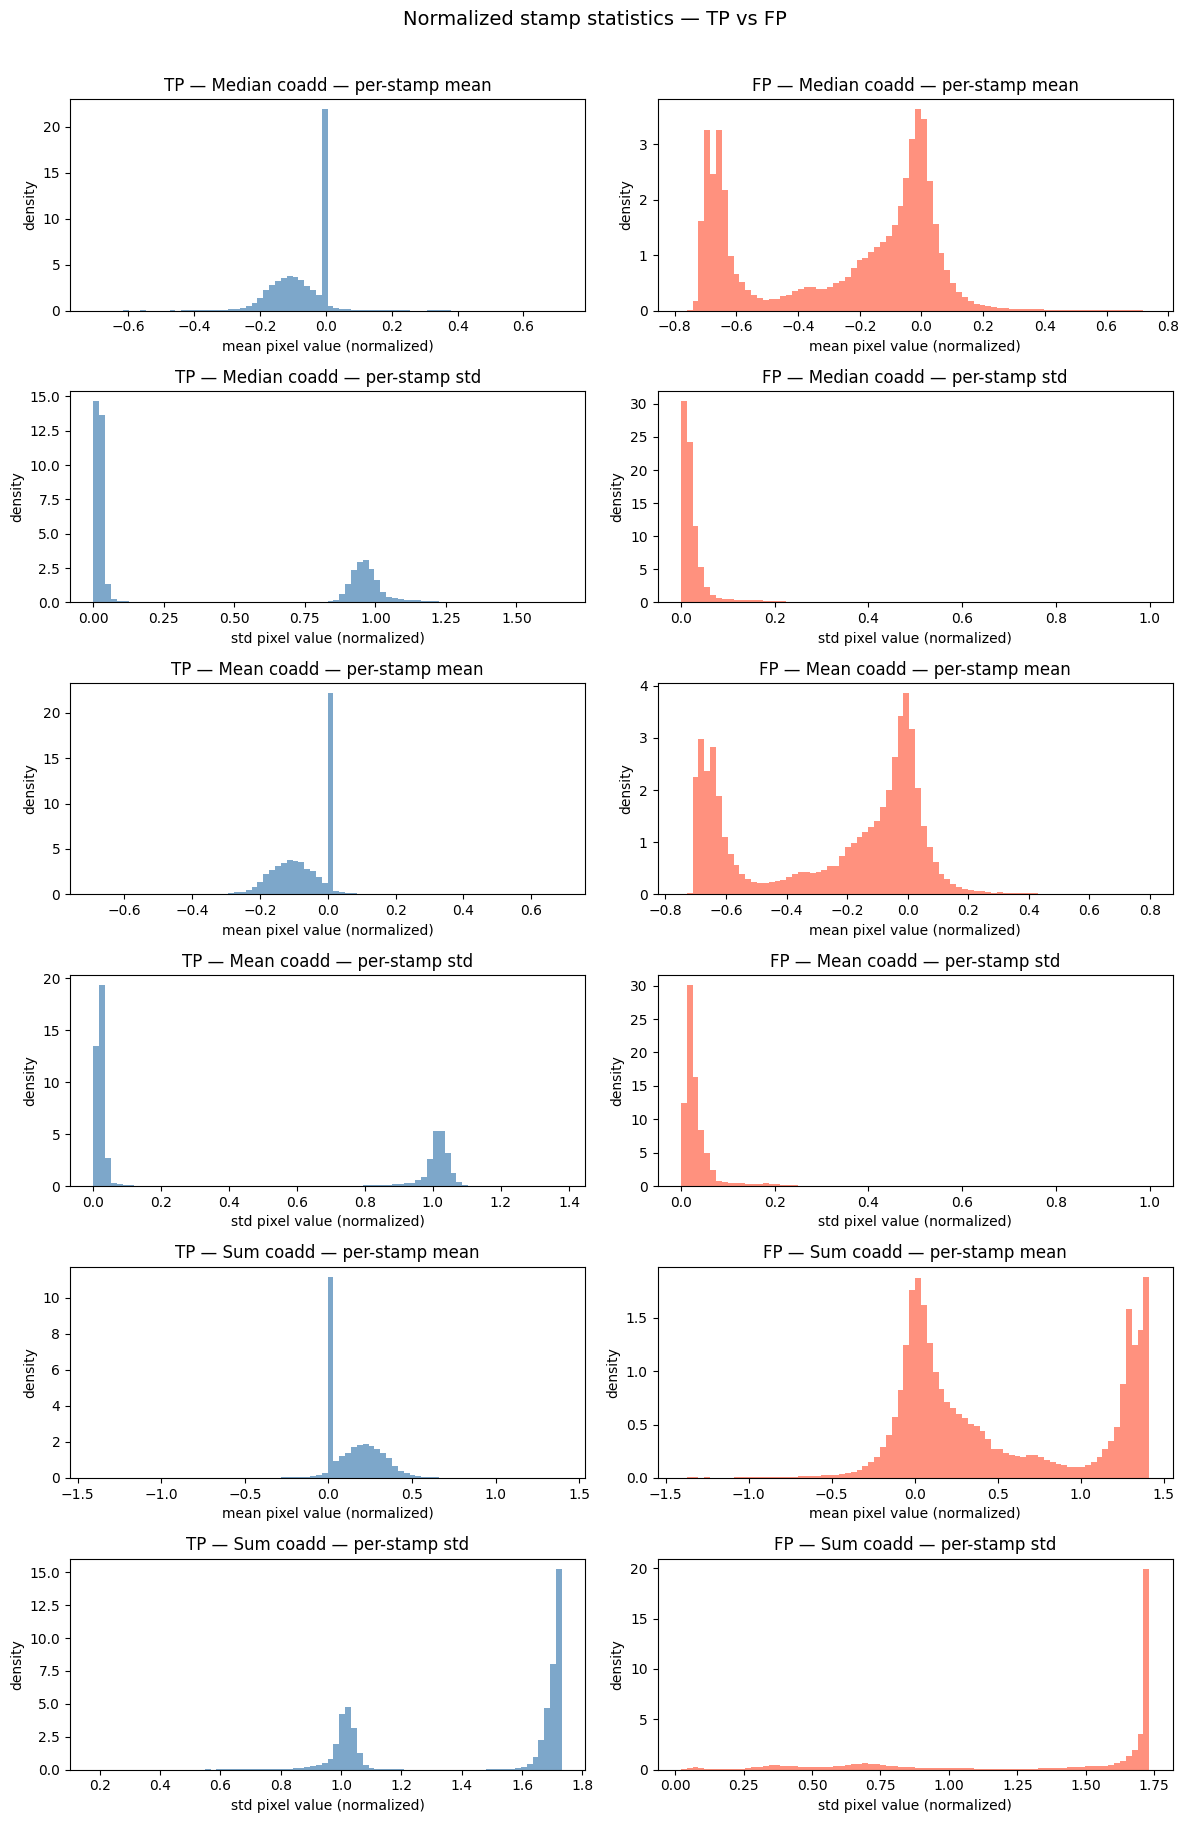

In [1]:
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = "/astro/store/epycn/users/htohfa/"

tp = np.load(DATA_DIR + "tp_combined_5_7sigma.npy")
fp = np.load(DATA_DIR + "fp_sub_300k.npy")

if fp.shape[1] > 3:
    fp = fp[:, :3]

def normalize(stamps):
    out  = stamps.astype(np.float32)
    flat = out.reshape(len(out), -1)
    mu   = flat.mean(axis=1, keepdims=True)
    sig  = flat.std(axis=1,  keepdims=True)
    sig[sig == 0] = 1.0
    return ((flat - mu) / sig).reshape(out.shape)

tp_norm = normalize(tp)
fp_norm = normalize(fp)

channel_names = ["Median coadd", "Mean coadd", "Sum coadd"]
fig, axes = plt.subplots(6, 2, figsize=(12, 18))
fig.suptitle("Normalized stamp statistics — TP vs FP", fontsize=14, y=1.01)

for ch in range(3):
    tp_means = tp_norm[:, ch].reshape(len(tp_norm), -1).mean(axis=1)
    fp_means = fp_norm[:, ch].reshape(len(fp_norm), -1).mean(axis=1)
    tp_stds  = tp_norm[:, ch].reshape(len(tp_norm), -1).std(axis=1)
    fp_stds  = fp_norm[:, ch].reshape(len(fp_norm), -1).std(axis=1)

    # mean row
    ax = axes[ch * 2, 0]
    ax.hist(tp_means, bins=80, color="steelblue", alpha=0.7, density=True)
    ax.set_title(f"TP — {channel_names[ch]} — per-stamp mean")
    ax.set_xlabel("mean pixel value (normalized)")
    ax.set_ylabel("density")

    ax = axes[ch * 2, 1]
    ax.hist(fp_means, bins=80, color="tomato", alpha=0.7, density=True)
    ax.set_title(f"FP — {channel_names[ch]} — per-stamp mean")
    ax.set_xlabel("mean pixel value (normalized)")
    ax.set_ylabel("density")

    # std row
    ax = axes[ch * 2 + 1, 0]
    ax.hist(tp_stds, bins=80, color="steelblue", alpha=0.7, density=True)
    ax.set_title(f"TP — {channel_names[ch]} — per-stamp std")
    ax.set_xlabel("std pixel value (normalized)")
    ax.set_ylabel("density")

    ax = axes[ch * 2 + 1, 1]
    ax.hist(fp_stds, bins=80, color="tomato", alpha=0.7, density=True)
    ax.set_title(f"FP — {channel_names[ch]} — per-stamp std")
    ax.set_xlabel("std pixel value (normalized)")
    ax.set_ylabel("density")

plt.tight_layout()
plt.savefig(DATA_DIR + "normalized_stats_tp_fp.png", dpi=150, bbox_inches="tight")
plt.show()

In [1]:
import os, sys, numpy as np, torch
DATA_DIR = "/astro/store/epycn/users/htohfa/"
print(f"CUDA: {torch.cuda.is_available()}")

CUDA: True


In [5]:
import hyrax.pytorch_ignite as _pi
from hyrax.datasets.data_provider import DataProvider
from torch.utils.data import WeightedRandomSampler, DataLoader
from ignite.engine import Events
import torch
import numpy as np


_original_dist_data_loader = _pi.dist_data_loader

def _balanced_dist_data_loader(dataset, config, split=False):
    loader, indexes = _original_dist_data_loader(dataset, config, split)

    inner = None
    if isinstance(dataset, DataProvider) and hasattr(dataset, "prepped_datasets"):
        inner = dataset.prepped_datasets.get("data", None)

    if inner is None or not hasattr(inner, "_labels"):
        return loader, indexes
    if not getattr(inner, "augment", False):
        return loader, indexes

    labels = np.array(inner._labels)[list(indexes)]
    n_tp = (labels == 1).sum()
    n_fp = (labels == 0).sum()

    if n_tp == 0 or n_fp == 0:
        return loader, indexes

    weights = np.where(labels == 1, 1.0 / n_tp, 1.0 / n_fp)
    sampler = WeightedRandomSampler(
        torch.tensor(weights, dtype=torch.float32),
        num_samples=len(weights),
        replacement=True,
    )
    kwargs = dict(config["data_loader"])
    kwargs["collate_fn"] = dataset.collate
    kwargs.pop("shuffle", None)
    new_loader = DataLoader(dataset, sampler=sampler, **kwargs)
    print(f"WeightedRandomSampler: {n_tp} TP, {n_fp} FP, {len(indexes)} total", flush=True)
    return new_loader, indexes

_pi.dist_data_loader = _balanced_dist_data_loader

_original_create_trainer = _pi.create_trainer

def _create_trainer_with_printing(model, config, results_directory):
    trainer = _original_create_trainer(model, config, results_directory)

    @trainer.on(Events.EPOCH_COMPLETED)
    def print_epoch_metrics(trainer):
        epoch = trainer.state.epoch
        epoch_metrics = getattr(model, "final_epoch_metrics", {})
        avg_train_loss = epoch_metrics.get("avg_train_loss", float("nan"))
        val_loss = getattr(model, "final_validation_metrics", {}).get("loss", float("nan"))
        val_auc  = epoch_metrics.get("val_auc", float("nan"))
        val_ap   = epoch_metrics.get("val_ap",  float("nan"))
        print(
            f"Epoch {epoch:3d}/50  "
            f"train={avg_train_loss:.4f}  "
            f"val_loss={val_loss:.4f}  "
            f"val_auc={val_auc:.4f}  "
            f"val_ap={val_ap:.4f}",
            flush=True,
        )

    return trainer

_pi.create_trainer = _create_trainer_with_printing


In [3]:
import kbmod_ml
from hyrax import Hyrax

h = Hyrax()

data_request = {
    "train": {
        "data": {
            "dataset_class": "kbmod_ml.data_sets.kbmod_stamps.KbmodStamps",
            "data_location": DATA_DIR,
            "primary_id_field": "object_id",
            "split_fraction": 0.70,
            "dataset_config": {
                "kbmod_ml": {
                    "augment": True,
                    "true_positive_file_name": "tp_combined_5_7sigma.npy",
                    "false_positive_file_name": "fp_sub_300k.npy",
                    "arrange_for_hyrax_splits": False,
                }
            }
        }
    },
    "validate": {
        "data": {
            "dataset_class": "kbmod_ml.data_sets.kbmod_stamps.KbmodStamps",
            "data_location": DATA_DIR,
            "primary_id_field": "object_id",
            "split_fraction": 0.15,
            "dataset_config": {
                "kbmod_ml": {
                    "augment": False,
                    "true_positive_file_name": "tp_combined_5_7sigma.npy",
                    "false_positive_file_name": "fp_sub_300k.npy",
                    "arrange_for_hyrax_splits": False,
                }
            }
        }
    },
}

h.set_config("data_request", data_request)
h.set_config("model.name", "kbmod_ml.models.hurum_net.KBModNet")
h.set_config("train.epochs", 50)
h.set_config("train.batch_size", 256)
h.set_config("optimizer", {"name": "torch.optim.AdamW"})
h.set_config('"torch.optim.AdamW"', {"lr": 3e-4, "weight_decay": 1e-4})
h.set_config("scheduler", {"name": "torch.optim.lr_scheduler.CosineAnnealingLR"})
h.set_config('"torch.optim.lr_scheduler.CosineAnnealingLR"', {"T_max": 50, "eta_min": 1e-6})
h.set_config("data_loader", {"batch_size": 256, "shuffle": False, "num_workers": 0, "pin_memory": True})

[2026-05-15 19:51:21,381 hyrax.config_utils:INFO] Merging external default config from /astro/users/htohfa/kbmod-ml/src/kbmod_ml/default_config.toml
[2026-05-15 19:51:21,394 hyrax.config_utils:INFO] Merging external default config from /astro/users/htohfa/kbmod-ml/src/kbmod_ml/default_config.toml
[2026-05-15 19:51:21,406 hyrax.config_utils:INFO] Merging external default config from /astro/users/htohfa/kbmod-ml/src/kbmod_ml/default_config.toml
[2026-05-15 19:51:21,417 hyrax.config_utils:INFO] Merging external default config from /astro/users/htohfa/kbmod-ml/src/kbmod_ml/default_config.toml
[2026-05-15 19:51:21,423 hyrax.config_utils:WARNING] Runtime config contains key or section 'batch_size' which has no default defined. All configuration keys and sections must be defined in /astro/users/htohfa/miniconda3/envs/kbmod_ml/lib/python3.11/site-packages/hyrax/hyrax_default_config.toml
[2026-05-15 19:51:21,429 hyrax.config_utils:INFO] Merging external default config from /astro/users/htohfa/k

In [4]:
print(h.config["data_loader"])

{'batch_size': 256, 'shuffle': False, 'num_workers': 0, 'pin_memory': True}


In [5]:
ds = h.prepare()
print("prepare() done")

Loaded 34440 true positive samples from /astro/store/epycn/users/htohfa/tp_combined_5_7sigma.npy
Loaded 300000 false positive samples from /astro/store/epycn/users/htohfa/fp_sub_300k.npy
Loaded 34440 true positive samples from /astro/store/epycn/users/htohfa/tp_combined_5_7sigma.npy
Loaded 300000 false positive samples from /astro/store/epycn/users/htohfa/fp_sub_300k.npy
[2026-05-15 19:51:26,113 hyrax.verbs.prepare:INFO] Finished Prepare


prepare() done


In [6]:
model = h.train()
print("Training complete")

Loaded 34440 true positive samples from /astro/store/epycn/users/htohfa/tp_combined_5_7sigma.npy
Loaded 300000 false positive samples from /astro/store/epycn/users/htohfa/fp_sub_300k.npy
Loaded 34440 true positive samples from /astro/store/epycn/users/htohfa/tp_combined_5_7sigma.npy
Loaded 300000 false positive samples from /astro/store/epycn/users/htohfa/fp_sub_300k.npy
[2026-05-15 19:51:41,415 hyrax.models.model_registry:INFO] Setting model's self.optimizer from config: torch.optim.AdamW with arguments: {'lr': 0.0003, 'weight_decay': 0.0001}.
[2026-05-15 19:51:41,416 hyrax.models.model_registry:WARNING] Both model and config define a criterion. Hyrax will use self.criterion defined in the model.
[2026-05-15 19:51:41,416 hyrax.models.model_registry:INFO] Using self.criterion defined in model: builtins.function
[2026-05-15 19:51:41,416 hyrax.models.model_registry:INFO] Setting model's self.scheduler from config: torch.optim.lr_scheduler.CosineAnnealingLR
with arguments: {'T_max': 50, '

WeightedRandomSampler: 24299 TP, 209809 FP, 234108 total


2026-05-15 19:51:41,499 ignite.distributed.auto.auto_dataloader INFO: Use data loader kwargs for dataset 'Name: data (primary': 
	{'sampler': <hyrax.pytorch_ignite.SubsetSequentialSampler object at 0x7fee09509650>, 'batch_size': 256, 'shuffle': False, 'num_workers': 0, 'pin_memory': True, 'collate_fn': <bound method DataProvider.collate of Name: data (primary dataset)
  Dataset class: kbmod_ml.data_sets.kbmod_stamps.KbmodStamps
  Data location: /astro/store/epycn/users/htohfa
  Fraction of data to use: 0.15
  Primary ID field: object_id
  Requested fields: classification, object_id, stamps
  Dataset config:
    kbmod_ml: {'augment': False, 'true_positive_file_name': 'tp_combined_5_7sigma.npy', 'false_positive_file_name': 'fp_sub_300k.npy', 'arrange_for_hyrax_splits': False}
>}
2026-05-15 19:51:41,582 ignite.distributed.auto.auto_model INFO: Apply torch DataParallel on model
2026-05-15 19:51:41,639 ignite.distributed.auto.auto_model INFO: Apply torch DataParallel on model
2026-05-15 19:

  0%|          | 1/915 [00:00<?, ?it/s]

Epoch   1/50  train=0.0197  val_loss=0.0198  val_auc=nan  val_ap=nan


...

Epoch  49/50  train=0.0000  val_loss=0.0599  val_auc=0.9842  val_ap=0.9318


  0%|          | 1/915 [00:00<?, ?it/s]

Epoch  50/50  train=0.0000  val_loss=0.0626  val_auc=0.9845  val_ap=0.9332


[2026-05-15 20:11:11,397 hyrax.pytorch_ignite:INFO] Total training time: 1161.51[s]
2026/05/15 20:11:11 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/05/15 20:11:11 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
[2026-05-15 20:11:11,512 hyrax.verbs.train:INFO] Finished Training


Training complete


Device: cuda
Loaded best_kbmodnet_5_7sigma.pt — 899,858 params
Loaded checkpoint_10_validator_loss=-0.0149.pt — 899,858 params
Loading stamps...
Stamps: 883,000  Real: 21,631  Bogus: 861,369
Saved probs to disk


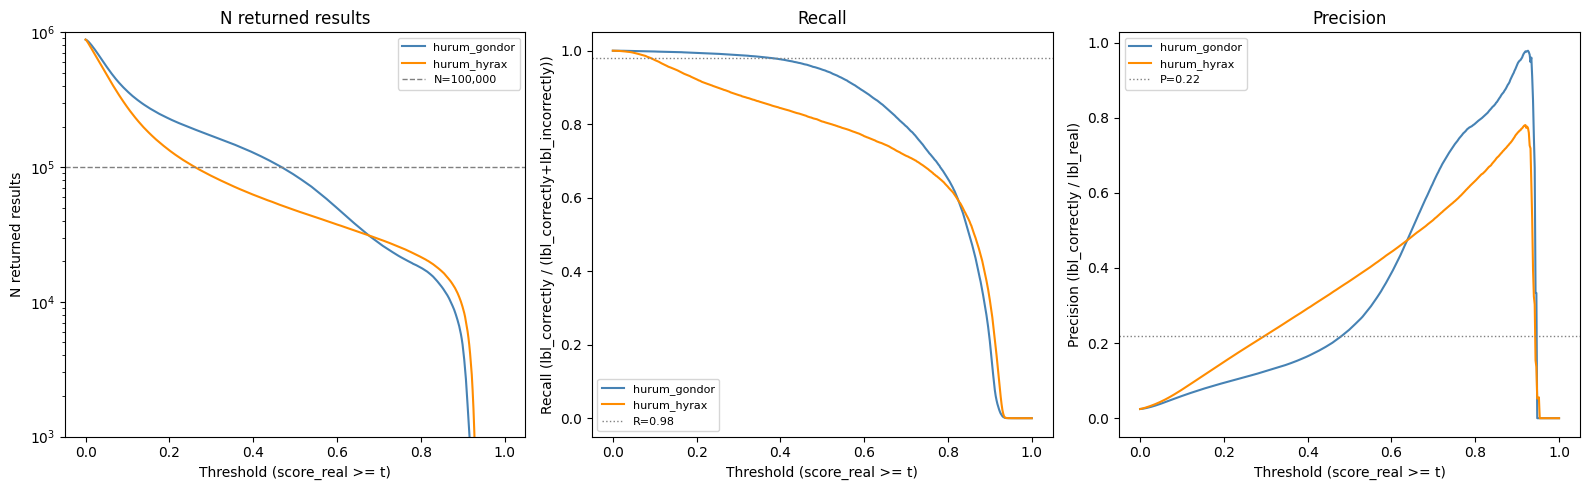

Saved → /astro/store/epyc/ssd/users/htohfa/comparison_gondor_vs_hyrax.png


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from astropy.table import Table

STAMP_DIR  = "/astro/store/epyc4/data4/kbmod_runs/DEEP/ml_classifier/for_hurum/"
XMATCH_DIR = "/astro/store/epyc4/data4/kbmod_runs/DEEP/5sigma_run/xmatch_catalogs/"
SAVE_DIR   = "/astro/store/epyc/ssd/users/htohfa/"

GONDOR_PT  = SAVE_DIR + "best_kbmodnet_5_7sigma.pt"
HYRAX_PT   = "/astro/users/htohfa/kbmod-ml/results/20260515-193323-train-ZDHW/checkpoint_10_validator_loss=-0.0149.pt"  

class SEBlock(nn.Module):
    def __init__(self, c, r=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(c, c // r), nn.ReLU(),
            nn.Linear(c // r, c), nn.Sigmoid(),
        )
    def forward(self, x):
        w = x.mean(dim=[2, 3])
        return x * self.fc(w).unsqueeze(-1).unsqueeze(-1)

class ResBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(c, c, 3, padding=1, bias=False), nn.BatchNorm2d(c), nn.GELU(),
            nn.Conv2d(c, c, 3, padding=1, bias=False), nn.BatchNorm2d(c),
        )
        self.se = SEBlock(c)
        self.act = nn.GELU()
    def forward(self, x):
        return self.act(self.se(self.conv(x)) + x)

class KBModNet(nn.Module):
    def __init__(self, in_channels=3, base=32, dropout=0.3):
        super().__init__()
        self.stem   = nn.Sequential(nn.Conv2d(in_channels, base, 3, padding=1, bias=False), nn.BatchNorm2d(base), nn.GELU())
        self.layer1 = nn.Sequential(ResBlock(base), ResBlock(base))
        self.down1  = nn.Sequential(nn.Conv2d(base, base*2, 3, stride=2, padding=1, bias=False), nn.BatchNorm2d(base*2), nn.GELU())
        self.layer2 = nn.Sequential(ResBlock(base*2), ResBlock(base*2))
        self.down2  = nn.Sequential(nn.Conv2d(base*2, base*4, 3, stride=2, padding=1, bias=False), nn.BatchNorm2d(base*4), nn.GELU())
        self.layer3 = nn.Sequential(ResBlock(base*4), ResBlock(base*4))
        self.head   = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(dropout), nn.Linear(base*4, base*2), nn.GELU(),
            nn.Dropout(dropout/2), nn.Linear(base*2, 2),
        )
    def forward(self, x):
        x = self.stem(x); x = self.layer1(x); x = self.down1(x)
        x = self.layer2(x); x = self.down2(x); x = self.layer3(x)
        return self.head(x)

def load_model(pt_path, device):
    raw = torch.load(pt_path, map_location=device, weights_only=False)

    # Handle all checkpoint formats
    if isinstance(raw, dict):
        # Hyrax full checkpoint
        if "model" in raw:
            state = raw["model"]
        # Plain state_dict
        elif any(k.startswith("stem.") for k in raw.keys()):
            state = raw
        # DataParallel-wrapped state_dict (keys start with "module.")
        elif any(k.startswith("module.stem.") for k in raw.keys()):
            state = {k.replace("module.", "", 1): v for k, v in raw.items()}
        else:
            raise ValueError(f"Unknown checkpoint format. Keys: {list(raw.keys())[:10]}")
    elif isinstance(raw, nn.Module):
        state = raw.state_dict()
    else:
        raise ValueError(f"Unknown checkpoint type: {type(raw)}")

    # Strip DataParallel prefix if present
    if any(k.startswith("module.") for k in state.keys()):
        state = {k.replace("module.", "", 1): v for k, v in state.items()}

    model = KBModNet()
    model.load_state_dict(state)
    model = model.to(device).eval()
    print(f"Loaded {pt_path.split('/')[-1]} — {sum(p.numel() for p in model.parameters()):,} params")
    return model

def normalize_stamps(stamps):
    out  = stamps.astype(np.float32)
    flat = out.reshape(len(out), -1)
    mu   = flat.mean(axis=1, keepdims=True)
    sig  = flat.std(axis=1,  keepdims=True)
    sig[sig == 0] = 1.0
    return ((flat - mu) / sig).reshape(out.shape)

class InferenceDataset(Dataset):
    def __init__(self, stamps):
        self.data = torch.tensor(normalize_stamps(stamps), dtype=torch.float32)
    def __len__(self):        return len(self.data)
    def __getitem__(self, i): return self.data[i]

def run_inference(model, stamps, device, batch_size=512):
    loader = DataLoader(
        InferenceDataset(stamps), batch_size=batch_size,
        shuffle=False, num_workers=4, pin_memory=True,
    )
    probs = []
    with torch.no_grad():
        for x in loader:
            probs.append(F.softmax(model(x.to(device)), dim=1)[:, 1].cpu().numpy())
    return np.concatenate(probs)

def make_comparison_plot(models_probs, labels, save_path, n_ref=100_000, p_ref=0.22, r_ref=0.98):
    """
    models_probs : dict of {legend_name: probs_array}
    labels       : ground truth array (1=real, 0=bogus), same length as each probs array
    """
    thresholds = np.linspace(0, 1, 500)
    colors = ["steelblue", "darkorange", "green", "red"]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    for (name, probs), color in zip(models_probs.items(), colors):
        n_returned, recalls, precisions = [], [], []
        n_real = labels.sum()

        for t in thresholds:
            preds = (probs >= t).astype(int)
            tp = ((preds == 1) & (labels == 1)).sum()
            fp = ((preds == 1) & (labels == 0)).sum()
            n_returned.append(tp + fp)
            recalls.append(tp / n_real if n_real > 0 else 0)
            precisions.append(tp / (tp + fp) if (tp + fp) > 0 else 0)

        n_returned  = np.array(n_returned)
        recalls     = np.array(recalls)
        precisions  = np.array(precisions)

        axes[0].plot(thresholds, n_returned,  color=color, label=name, lw=1.5)
        axes[0].set_ylim(1e3,1e6)
        axes[1].plot(thresholds, recalls,     color=color, label=name, lw=1.5)
        axes[2].plot(thresholds, precisions,  color=color, label=name, lw=1.5)

    # Reference lines
    axes[0].axhline(n_ref, color="gray",    linestyle="--", lw=1, label=f"N={n_ref:,}")
    axes[1].axhline(r_ref, color="gray",    linestyle=":",  lw=1, label=f"R={r_ref}")
    axes[2].axhline(p_ref, color="gray",    linestyle=":",  lw=1, label=f"P={p_ref}")

    axes[0].set_yscale("log")
    for ax, title in zip(axes, ["N returned results", "Recall", "Precision"]):
        ax.set_xlabel("Threshold (score_real >= t)")
        ax.set_title(title)
        ax.legend(fontsize=8)

    axes[0].set_ylabel("N returned results")
    axes[1].set_ylabel("Recall (lbl_correctly / (lbl_correctly+lbl_incorrectly))")
    axes[2].set_ylabel("Precision (lbl_correctly / lbl_real)")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# Load models
gondor = load_model(GONDOR_PT, device)
hyrax  = load_model(HYRAX_PT,  device)

# Load the full 5sigma dataset with xmatch labels
print("Loading stamps...")
stamps_5s = np.load(STAMP_DIR + "DEEP_lh5_stamps.npy")
uuids_5s  = np.array([str(u).strip() for u in
                       np.load(STAMP_DIR + "DEEP_lh5_uuids.npy", allow_pickle=True)])
xmatch    = Table.read(XMATCH_DIR + "xmatch_catalog.angular_50percent_cut.ecsv",
                       format="ascii.ecsv")
real_uuids = set(str(u).strip() for u in xmatch["uuid"])
labels     = np.array([1 if u in real_uuids else 0 for u in uuids_5s])

print(f"Stamps: {len(stamps_5s):,}  Real: {labels.sum():,}  Bogus: {(labels==0).sum():,}")

# Run inference
print("Running inference — hurum_gondor...")
probs_gondor = run_inference(gondor, stamps_5s, device)

print("Running inference — hurum_hyrax...")
probs_hyrax  = run_inference(hyrax,  stamps_5s, device)

# Save probs so you don't have to rerun inference
np.save(SAVE_DIR + "probs_gondor_5s.npy", probs_gondor)
np.save(SAVE_DIR + "probs_hyrax_5s.npy",  probs_hyrax)
np.save(SAVE_DIR + "labels_5s.npy",        labels)
print("Saved probs to disk")

# Plot
make_comparison_plot(
    models_probs={
        "hurum_gondor": probs_gondor,
        "hurum_hyrax":  probs_hyrax,
    },
    labels=labels,
    save_path=SAVE_DIR + "comparison_gondor_vs_hyrax.png",
)